# Question 7: RL with Function Approximation + DQN


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)


## Part 1: TD(0) with Linear Function Approximation (Value Prediction)
**Environment:** Random Walk
* **States:** $\{0, 1, \dots, 10\}$.
* **Terminals:** $0$ (Left) and $10$ (Right).
* **Start:** State $5$.
* **Actions:** Left or Right (equiprobable $0.5$).
* **Reward:** $+1$ if transitioning to state $10$, else $0$.
* **Gamma:** $1.0$.

### Task A: Implement the Environment

In [8]:
class RandomWalkEnv:
    def __init__(self):
        self.state = 5
        self.terminal_states = [0, 10]
        
    def reset(self):
        self.state = 5
        return self.state
    
    def step(self):
        # 0: Left, 1: Right
        action = np.random.choice([-1, 1])
        next_state = self.state + action
        
        # Check constraints (though logic implies we won't go beyond 0 or 10)
        next_state = max(0, min(10, next_state))
        
        reward = 0
        done = False
        
        if next_state == 10:
            reward = 1
            done = True
        elif next_state == 0:
            reward = 0  # No reward for left terminal
            done = True
            
        self.state = next_state
        return next_state, reward, done

# Verification: Run 5 episodes
print("--- Random Walk Verification (Clean) ---")
env = RandomWalkEnv()
for episode in range(1, 6):
    state = env.reset()
    traj = [state]
    rewards = []
    while True:
        next_state, r, done = env.step()
        traj.append(int(next_state))
        rewards.append(int(r))
        if done:
            break
    print(f"Ep {episode}: Trajectory {traj}, Rewards {rewards}")

--- Random Walk Verification (Clean) ---
Ep 1: Trajectory [5, 6, 7, 8, 9, 10], Rewards [0, 0, 0, 0, 1]
Ep 2: Trajectory [5, 6, 7, 8, 7, 6, 7, 8, 9, 10], Rewards [0, 0, 0, 0, 0, 0, 0, 0, 1]
Ep 3: Trajectory [5, 6, 7, 8, 9, 8, 9, 8, 9, 10], Rewards [0, 0, 0, 0, 0, 0, 0, 0, 1]
Ep 4: Trajectory [5, 4, 5, 4, 5, 6, 5, 6, 5, 6, 5, 4, 5, 6, 5, 6, 7, 8, 7, 6, 5, 4, 3, 2, 1, 0], Rewards [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Ep 5: Trajectory [5, 4, 5, 4, 5, 6, 7, 6, 5, 4, 3, 4, 3, 2, 1, 0], Rewards [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Task B: Feature Map (State Aggregation)
Implement a feature map $\phi(s)$ using **3 bins**:
* Bin 1: $\{1, 2, 3\}$
* Bin 2: $\{4, 5, 6\}$
* Bin 3: $\{7, 8, 9\}$
* Terminal states $(0, 10)$ return a zero vector.

In [7]:
def get_feature_vector(state, num_bins=3):
    """
    Returns a feature vector for the given state.
    num_bins=3 corresponds to the coarse aggregation.
    num_bins=9 corresponds to one-hot encoding (Task E).
    """
    if state == 0 or state == 10:
        return np.zeros(num_bins)
    
    features = np.zeros(num_bins)
    
    if num_bins == 3:
        # Bin 1: 1-3, Bin 2: 4-6, Bin 3: 7-9
        if 1 <= state <= 3:
            features[0] = 1
        elif 4 <= state <= 6:
            features[1] = 1
        elif 7 <= state <= 9:
            features[2] = 1
            
    elif num_bins == 9:
        # One-hot for states 1-9
        # State s maps to index s-1
        if 1 <= state <= 9:
            features[state - 1] = 1
            
    return features

# Sanity Check
print("\n--- Feature Map Sanity Check (3 bins) ---")
print(f"phi(2) (Bin 1): {get_feature_vector(2, num_bins=3)}")
print(f"phi(5) (Bin 2): {get_feature_vector(5, num_bins=3)}")
print(f"phi(9) (Bin 3): {get_feature_vector(9, num_bins=3)}")
print(f"phi(0) (Term.): {get_feature_vector(0, num_bins=3)}")


--- Feature Map Sanity Check (3 bins) ---
phi(2) (Bin 1): [1. 0. 0.]
phi(5) (Bin 2): [0. 1. 0.]
phi(9) (Bin 3): [0. 0. 1.]
phi(0) (Term.): [0. 0. 0.]


### Task C & D: Linear TD(0) Training and Generalization
$V(s) \approx w^T \phi(s)$.
The TD(0) update rule for the weight vector $w$:
$$\delta = R + \gamma \hat{v}(S', w) - \hat{v}(S, w)$$
$$w \leftarrow w + \alpha \cdot \delta \cdot \nabla \hat{v}(S, w)$$
Since $\hat{v}$ is linear, $\nabla \hat{v}(S, w) = \phi(S)$.

In [ ]:
def train_linear_td(episodes=3000, alpha=0.05, gamma=1.0, num_bins=3):
    # Initialize weights
    w = np.zeros(num_bins)
    env = RandomWalkEnv()
    
    # Track Value estimates for states 1..9 over time (for logging)
    # Just storing final values for plotting primarily
    
    for ep in range(episodes):
        state = env.reset()
        
        while True:
            # Get features for current state
            x_s = get_feature_vector(state, num_bins)
            v_s = np.dot(w, x_s)
            
            # Step
            next_state, reward, done = env.step()
            
            # Get features for next state
            x_next = get_feature_vector(next_state, num_bins)
            v_next = np.dot(w, x_next)
            
            # TD Error
            delta = reward + gamma * v_next - v_s
            
            # Weight update
            w += alpha * delta * x_s
            
            if done:
                break
            state = next_state
            
    return w

# Train with 3 bins
w_3bins = train_linear_td(episodes=3000, alpha=0.05, num_bins=3)

# Calculate V(s) for all states 1-9
V_3bins = [np.dot(w_3bins, get_feature_vector(s, 3)) for s in range(1, 10)]

print("\n--- Learned Weights (3 Bins) ---")
print(w_3bins)


--- Learned Weights (3 Bins) ---
[0.43381963 0.61223633 0.72670321]


### Task E: Comparison (3 Bins vs 9 Bins)

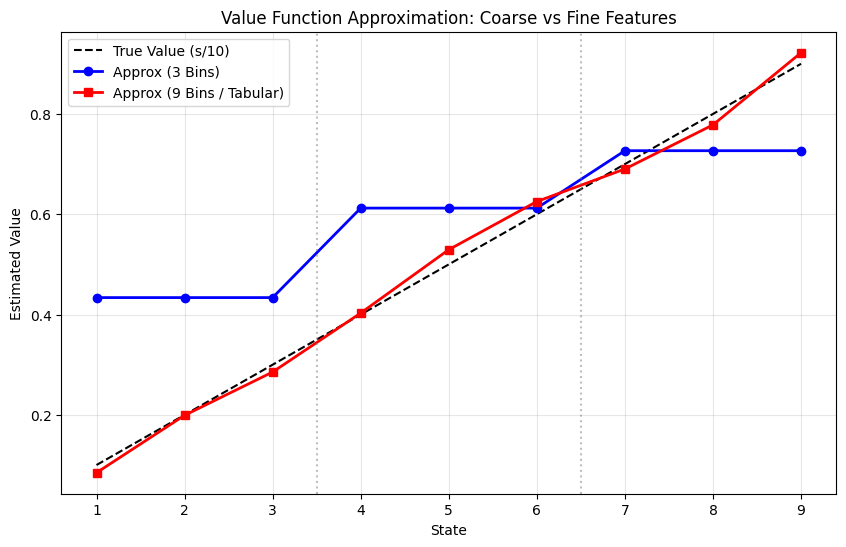

In [11]:
# Train with 9 bins (One-hot)
w_9bins = train_linear_td(episodes=3000, alpha=0.05, num_bins=9)
V_9bins = [np.dot(w_9bins, get_feature_vector(s, 9)) for s in range(1, 10)]

# Plotting Task D & E
plt.figure(figsize=(10, 6))
states = range(1, 10)
true_values = [s/10.0 for s in states] # Theoretical True Values

plt.plot(states, true_values, 'k--', label='True Value (s/10)')
plt.plot(states, V_3bins, 'b-o', label='Approx (3 Bins)', linewidth=2)
plt.plot(states, V_9bins, 'r-s', label='Approx (9 Bins / Tabular)', linewidth=2)

# Mark Bin Boundaries for 3-bin case
plt.axvline(x=3.5, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=6.5, color='gray', linestyle=':', alpha=0.5)

plt.title("Value Function Approximation: Coarse vs Fine Features")
plt.xlabel("State")
plt.ylabel("Estimated Value")
plt.xticks(states)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Part 2: Minimal DQN

**Task F & G:** Implementation of a DQN Agent on `CartPole-v1`.

In [12]:
ENV_NAME = 'CartPole-v1'
GAMMA = 0.99
BATCH_SIZE = 64
REPLAY_SIZE = 10000
LR = 1e-3
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 0.995
TARGET_UPDATE_FREQ = 500
NUM_EPISODES = 300 

In [13]:

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (np.array(state), np.array(action), np.array(reward), 
                np.array(next_state), np.array(done))
    
    def __len__(self):
        return len(self.buffer)

In [14]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.fc(x)


In [15]:
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=LR)
        self.loss_fn = nn.MSELoss()
        self.replay_buffer = ReplayBuffer(REPLAY_SIZE)
        
        self.epsilon = EPS_START
        self.steps = 0
        
    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0)
                q_values = self.q_net(state_t)
                return q_values.argmax().item()
            
    def train_step(self):
        if len(self.replay_buffer) < BATCH_SIZE:
            return
        
        # Sample Batch
        s, a, r, ns, d = self.replay_buffer.sample(BATCH_SIZE)
        
        s_t = torch.FloatTensor(s)
        a_t = torch.LongTensor(a).unsqueeze(1)
        r_t = torch.FloatTensor(r).unsqueeze(1)
        ns_t = torch.FloatTensor(ns)
        d_t = torch.FloatTensor(d).unsqueeze(1)
        
        # Compute Q(s, a)
        q_values = self.q_net(s_t).gather(1, a_t)
        
        # Compute Target: r + gamma * max Q_target(s', a')
        with torch.no_grad():
            next_q_values = self.target_net(ns_t).max(1)[0].unsqueeze(1)
            target_q = r_t + GAMMA * next_q_values * (1 - d_t)
            
        # Loss & Backprop
        loss = self.loss_fn(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update Target Network
        self.steps += 1
        if self.steps % TARGET_UPDATE_FREQ == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
            
        # Decay Epsilon
        if self.epsilon > EPS_END:
            self.epsilon *= EPS_DECAY


In [16]:
env = gym.make(ENV_NAME)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DQNAgent(state_dim, action_dim)

episode_rewards = []
epsilon_history = []

print(f"--- Starting DQN Training on {ENV_NAME} ---")

for episode in range(NUM_EPISODES):
    state, _ = env.reset(seed=SEED + episode) # Seed for reproducibility
    total_reward = 0
    done = False
    truncated = False
    
    while not (done or truncated):
        action = agent.select_action(state)
        next_state, reward, done, truncated, _ = env.step(action)
        
        # Add to buffer
        agent.replay_buffer.add(state, action, reward, next_state, done or truncated)
        
        # Train
        agent.train_step()
        
        state = next_state
        total_reward += reward
        
    episode_rewards.append(total_reward)
    epsilon_history.append(agent.epsilon)
    
    if (episode + 1) % 20 == 0:
        avg_ret = np.mean(episode_rewards[-20:])
        print(f"Episode {episode+1}/{NUM_EPISODES} | Avg Return (Last 20): {avg_ret:.1f} | Epsilon: {agent.epsilon:.3f}")

env.close()

--- Starting DQN Training on CartPole-v1 ---
Episode 20/300 | Avg Return (Last 20): 18.6 | Epsilon: 0.212
Episode 40/300 | Avg Return (Last 20): 12.9 | Epsilon: 0.058
Episode 60/300 | Avg Return (Last 20): 22.2 | Epsilon: 0.050
Episode 80/300 | Avg Return (Last 20): 11.4 | Epsilon: 0.050
Episode 100/300 | Avg Return (Last 20): 31.4 | Epsilon: 0.050
Episode 120/300 | Avg Return (Last 20): 209.3 | Epsilon: 0.050
Episode 140/300 | Avg Return (Last 20): 228.4 | Epsilon: 0.050
Episode 160/300 | Avg Return (Last 20): 230.3 | Epsilon: 0.050
Episode 180/300 | Avg Return (Last 20): 186.4 | Epsilon: 0.050
Episode 200/300 | Avg Return (Last 20): 125.4 | Epsilon: 0.050
Episode 220/300 | Avg Return (Last 20): 123.9 | Epsilon: 0.050
Episode 240/300 | Avg Return (Last 20): 138.3 | Epsilon: 0.050
Episode 260/300 | Avg Return (Last 20): 194.9 | Epsilon: 0.050
Episode 280/300 | Avg Return (Last 20): 163.6 | Epsilon: 0.050
Episode 300/300 | Avg Return (Last 20): 131.1 | Epsilon: 0.050


### Task G: Evaluation and Plots


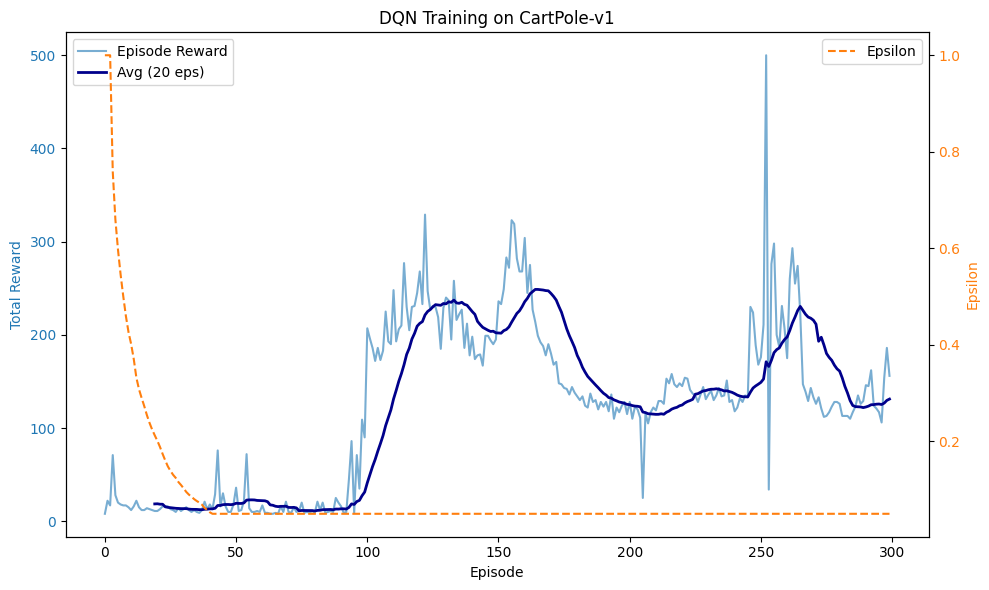

In [18]:
# Plot Training Results
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward', color=color)
ax1.plot(episode_rewards, color=color, alpha=0.6, label='Episode Reward')
# Rolling average
rolling_avg = np.convolve(episode_rewards, np.ones(20)/20, mode='valid')
ax1.plot(range(19, len(episode_rewards)), rolling_avg, color='darkblue', linewidth=2, label='Avg (20 eps)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:orange'
ax2.set_ylabel('Epsilon', color=color)
ax2.plot(epsilon_history, color=color, linestyle='--', label='Epsilon')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title(f"DQN Training on {ENV_NAME}")
fig.tight_layout()
plt.show()


### ‌Bonus Task (Ablation)

In [22]:
class AblationDQNAgent(DQNAgent):
    def __init__(self, state_dim, action_dim, use_target_net=True, use_replay=True):
        super().__init__(state_dim, action_dim)
        self.use_target_net = use_target_net
        self.use_replay = use_replay
        
        if not self.use_replay:
            self.replay_buffer = ReplayBuffer(BATCH_SIZE) 
            
    def train_step(self):
        if len(self.replay_buffer) < BATCH_SIZE:
            return
        
        # Sampling logic
        if self.use_replay:
            s, a, r, ns, d = self.replay_buffer.sample(BATCH_SIZE)
        else:
            batch = list(self.replay_buffer.buffer)
            s, a, r, ns, d = zip(*batch)
            self.replay_buffer.buffer.clear() 
            s = np.array(s)
            a = np.array(a)
            r = np.array(r)
            ns = np.array(ns)
            d = np.array(d)

        s_t = torch.FloatTensor(s)
        a_t = torch.LongTensor(a).unsqueeze(1)
        r_t = torch.FloatTensor(r).unsqueeze(1)
        ns_t = torch.FloatTensor(ns)
        d_t = torch.FloatTensor(d).unsqueeze(1)
        
        q_values = self.q_net(s_t).gather(1, a_t)
        
        # Compute Target
        with torch.no_grad():
            if self.use_target_net:
                next_q_values = self.target_net(ns_t).max(1)[0].unsqueeze(1)
            else:
                next_q_values = self.q_net(ns_t).max(1)[0].unsqueeze(1)
                
            target_q = r_t + GAMMA * next_q_values * (1 - d_t)
            
        loss = self.loss_fn(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        if self.use_target_net:
            self.steps += 1
            if self.steps % TARGET_UPDATE_FREQ == 0:
                self.target_net.load_state_dict(self.q_net.state_dict())


In [23]:
def run_experiment(name, use_target, use_replay, episodes=50): 
    # Re-create environment to avoid any lingering state
    env = gym.make(ENV_NAME)
    agent = AblationDQNAgent(state_dim, action_dim, use_target, use_replay)
    rewards = []
    
    print(f"--- Running {name} ---")
    for ep in range(episodes):
        state, _ = env.reset(seed=SEED+ep)
        total_reward = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state)
            
            # FIX: Update done and truncated variables correctly
            next_state, r, done, truncated, _ = env.step(action)
            
            agent.replay_buffer.add(state, action, r, next_state, done or truncated)
            agent.train_step()
            state = next_state
            total_reward += r
        
        rewards.append(total_reward)
        if (ep+1) % 10 == 0:
            print(f"Ep {ep+1}: Avg Reward {np.mean(rewards[-10:]):.1f}")
            
    return rewards


In [24]:
rewards_no_target = run_experiment("No Target Net", use_target=False, use_replay=True, episodes=50)
rewards_no_replay = run_experiment("No Replay Buffer", use_target=True, use_replay=False, episodes=50)

--- Running No Target Net ---
Ep 10: Avg Reward 18.8
Ep 20: Avg Reward 23.2
Ep 30: Avg Reward 20.5
Ep 40: Avg Reward 16.6
Ep 50: Avg Reward 16.3
--- Running No Replay Buffer ---
Ep 10: Avg Reward 24.0
Ep 20: Avg Reward 17.6
Ep 30: Avg Reward 18.2
Ep 40: Avg Reward 24.3
Ep 50: Avg Reward 15.8


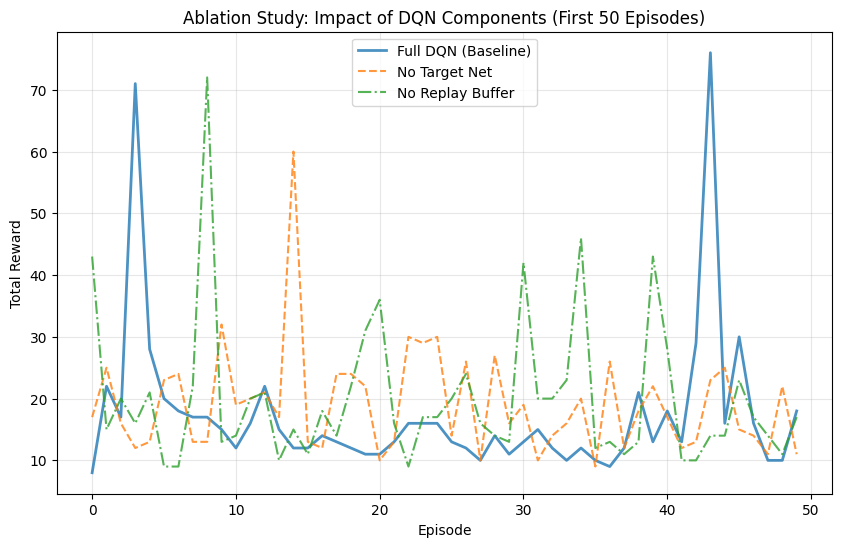

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(episode_rewards[:50], label='Full DQN (Baseline)', alpha=0.8, linewidth=2)
plt.plot(rewards_no_target, label='No Target Net', alpha=0.8, linestyle='--')
plt.plot(rewards_no_replay, label='No Replay Buffer', alpha=0.8, linestyle='-.')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Ablation Study: Impact of DQN Components (First 50 Episodes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()